<a href="https://colab.research.google.com/github/shiva1304/Algorithm_Visualizer/blob/main/DL_totural_no.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading and preparing data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model... this will take a moment.
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 124s 130ms/step - accuracy: 0.9070 - loss: 0.3068 - val_accuracy: 0.9751 - val_loss: 0.0736
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 123ms/step - accuracy: 0.9633 - loss: 0.1253 - val_accuracy: 0.9628 - val_loss: 0.1129
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 122ms/step - accuracy: 0.9712 - loss: 0.1005 - val_accuracy: 0.9828 - val_loss: 0.0510
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 123ms/step - accuracy: 0.9746 - loss: 0.0892 - val_accuracy: 0.9830 - val_loss: 0.0559
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 114s 121ms/step - accuracy: 0.9779 - loss: 0.0754 - val_accuracy: 0.9847 - val_loss: 0.0575
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 122ms/step - accuracy: 0.9781 - loss: 0.0739 - val_accuracy: 0.9877 - val_loss: 0.0419
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 121ms/step - accuracy: 0.9803 - loss: 0.0673 - val_accuracy: 0.9909 - val_loss: 0.0337
Epoch 8/10
938/938 ━━━━━━━━━━━━━━

Saving monalisa.jpeg to monalisa (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


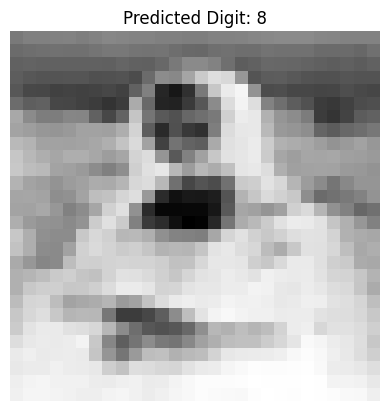

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

print("Loading and preparing data...")
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train[..., tf.newaxis].astype("float32") / 255.0
x_test = x_test[..., tf.newaxis].astype("float32") / 255.0

datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1, width_shift_range=0.1, height_shift_range=0.1)
datagen.fit(x_train)

-
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


print("Training model... this will take a moment.")
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(datagen.flow(x_train, y_train, batch_size=64), epochs=10, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)


def predict_custom_image(trained_model):
    print("\nPlease upload an image file:")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

    img = Image.open(file_name).convert('L')
    img = img.resize((28, 28))
    img = ImageOps.invert(img) # Inverts black/white for MNIST compatibility

    img_array = np.array(img).astype('float32') / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)
    prediction = trained_model.predict(img_array)
    predicted_digit = np.argmax(prediction)


    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted Digit: {predicted_digit}')
    plt.axis('off')
    plt.show()

# After training completes, this function will automatically trigger the upload prompt
predict_custom_image(model)